In [1]:
using CMPSExcitations, LiebLinigerBetheAnsatz
using CMPSExcitations: pitick

In [2]:
function projection_matrix(D, R)
    dim_in = D^2 + D      # input: E (DxD) + F (D)
    dim_out = 2 * D^2     # output: W1, W2 (both DxD)
    P = zeros(ComplexF64, dim_out, dim_in)

    Dr, M = eigen(R)

    for j in 1:dim_in
        e = zeros(Float64, dim_in)
        e[j] = 1.0

        E = reshape(view(e, 1:D^2), D, D)
        F = view(e, D^2+1:dim_in)

        W1 = E - M * Diagonal(F) / M
        W2 = E + M * Diagonal(F) / M

        P[:, j] = vcat(vec(W1), vec(W2))
    end

    return Matrix(qr(P).Q) # moves to an orthogonal projection
end

function excitation_matrix(Heff, D)
    dim = 2 * D^2
    M = zeros(ComplexF64, dim, dim)

    for j in 1:dim
        e = zeros(ComplexF64, dim)
        e[j] = 1.0
        W1 = reshape(view(e, 1:D^2), D, D)
        W2 = reshape(view(e, D^2+1:dim), D, D)
        W1p, W2p = Heff((Constant(W1), Constant(W2)))
        M[:, j] = vcat(vec(W1p[]), vec(W2p[]))
    end

    return M
end

function excitation_matrix_left(Heff, D, ρR)
    dim = 2 * D^2
    M = zeros(ComplexF64, dim, dim)
    factor = sqrt(ρR)

    for j in 1:dim
        e = zeros(ComplexF64, dim)
        e[j] = 1.0
        W1 = reshape(view(e, 1:D^2), D, D)
        W2 = reshape(view(e, D^2+1:dim), D, D)
        W1 = W1 * factor
        W2 = W2 * factor
        W1p, W2p = Heff((Constant(W1), Constant(W2)))
        W1p = W1p / factor
        W2p = W2p / factor
        M[:, j] = vcat(vec(W1p[]), vec(W2p[]))
    end

    return M
end

function leftcanonical(state, cmps=false)
    leftgauge!(state)
    r = rightenv(state)[1][]
    D, U = eigen(r)
    Q = U \ state.Q[] * U
    R = U \ state.Rs[1][] * U
    return (cmps) ? InfiniteCMPS(Constant(Q), (Constant(R), Constant(R))) : (Q, R)
end

function left2centre_matrix(ρR)
    D = size(ρR, 1)
    dim = 2 * D^2
    M = zeros(ComplexF64, dim, dim)
    factor = sqrt(ρR) # generally can be any C such that CC' = r

    for j in 1:dim
        e = zeros(ComplexF64, dim)
        e[j] = 1.0
        W1 = reshape(view(e, 1:D^2), D, D)
        W2 = reshape(view(e, D^2+1:dim), D, D)
        X1, X2 = W1 * factor, W2 * factor
        M[:, j] = vcat(vec(X1), vec(X2))
    end

    return M
end

function leftgaugetv(Q, R, V, W1, W2, p)
    # assuming Q, R are in cMPS left gauge
    X, _ = linsolve(-R' * (W1 + W2) - V) do X
        (Q * X - X * Q) + 1im * p * X + 2 * R' * (R * X - X * R)
    end

    return V + (Q * X - X * Q) + 1im * p * X, W1 + (R * X - X * R), W2 + (R * X - X * R)
end

leftgaugetv (generic function with 1 method)

In [3]:
Hsingle_cll(c, μ) = ∫(2 * ∂ψ̂' * ∂ψ̂ - 2 * μ * ψ̂' * ψ̂ + 4 * c * (ψ̂')^2 * ψ̂^2, (-Inf, +Inf));
Hcoupled(c, μ) = ∫(
    (∂ψ̂₁' * ∂ψ̂₁ - μ * ψ̂₁' * ψ̂₁ + c * (ψ̂₁')^2 * ψ̂₁^2 +
     ∂ψ̂₂' * ∂ψ̂₂ - μ * ψ̂₂' * ψ̂₂ + c * (ψ̂₂')^2 * ψ̂₂^2 +
     c * (ψ̂₁') * (ψ̂₂') * ψ̂₂ * ψ̂₁ + c * (ψ̂₂') * (ψ̂₁') * ψ̂₁ * ψ̂₂), (-Inf, +Inf));

Hsingle_ll(c, μ) = ∫(∂ψ̂' * ∂ψ̂ - μ * ψ̂' * ψ̂ + c * (ψ̂')^2 * ψ̂^2, (-Inf, +Inf));

In [4]:
c, μ = 10., 5.
tol = 1e-10
Ds = [8, 12]
D = maximum(Ds)

HLL = Hsingle_cll(c, μ)
stateLL = find_groundstate(Ds, HLL, YangGaudinCMPS, optalg=LBFGS(80; verbosity=1, maxiter=7000, gradtol=tol), gradtol=tol)
println("Energy density: ", expval(HLL.h, stateLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateLL)[], "\n Order parameter: ", expval(ψ̂, stateLL)[])
println("------------")
HCLL = Hcoupled(c, μ)
stateCLL = InfiniteCMPS(stateLL.Q, (stateLL.Rs[1], stateLL.Rs[1]));
leftgauge!(stateCLL)
println("Energy density: ", expval(HCLL.h, stateCLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateCLL)[], "\n Order parameter: ", expval(ψ̂, stateCLL)[])

Optimizing D=8


┌ Warning: The function `inner` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Constant{Matrix{Float64}}}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:196
┌ Warning: The function `scale` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Float64}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:67
┌ Warning: The function `add!!` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Constant{Matrix{Float64}}, Float64, VectorInterface.One}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:163
┌ Warning: The function `scalartype` is not implemented for (values of) type `Constant

D = 8 | YangGaudinCMPS{Constant{Matrix{Float64}}, 1}
 14.808241 seconds (61.30 M allocations: 3.175 GiB, 2.29% gc time, 73.92% compilation time: <1% of which was recompilation)
---------------
Optimizing D=12


┌ Info: YangGaudinCMPS ground state: converged after 454 iterations: e = -2.761265509087, ‖∇e‖ = 9.3004e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:118
┌ Info: YangGaudinCMPS ground state: initialization with e = -2.761265509238
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:106
┌ Info: LBFGS: converged after 431 iterations: f = -2.764113438366, ‖∇f‖ = 5.5734e-11
└ @ OptimKit /home/ashankar/.julia/packages/OptimKit/xpmbV/src/lbfgs.jl:138


D = 12 | YangGaudinCMPS{Constant{Matrix{Float64}}, 1}
 16.040302 seconds (10.66 M allocations: 1.481 GiB, 1.34% gc time, 1.69% compilation time)
---------------
Energy density: 

┌ Info: YangGaudinCMPS ground state: converged after 432 iterations: e = -2.764113438366, ‖∇e‖ = 5.5734e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:118


-2.7641134383655803
 Particle density: 0.43688623605501903
 Order parameter: 0.3282139401360227
------------
Energy density: -2.7641134383658548
 Particle density: 0.43688623605501686
 Order parameter: 0.3282139401360303


┌ Warning: The function `add` is not implemented for (values of) type `Tuple{Constant{Matrix{ComplexF64}}, Constant{Matrix{ComplexF64}}, ComplexF64, ComplexF64}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:131


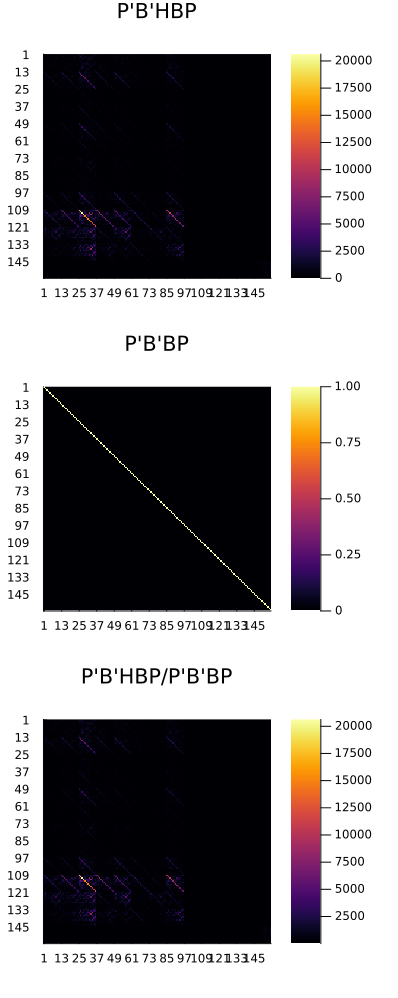

In [5]:
# stateCLL = leftcanonical(stateCLL, true)
P = projection_matrix(D, stateLL.Rs[1][])

ρR = rightenv(stateCLL)[1][]
ρR ./= tr(ρR)
B = left2centre_matrix(ρR)

space = InfiniteCMPSExcitationSpace(0, stateCLL, stateCLL)
Heff = excitation_matrix_left(excitation_operator(HCLL, space), D, ρR);

Hf = P' * Heff * P
Nf = P' * P

p1 = heatmap(abs.(Hf), yflip=true, size=(400, 400), xticks=1:D:D^2+D, yticks=1:D:D^2+D, title="P'B'HBP")
p2 = heatmap(abs.(Nf), yflip=true, size=(400, 400), xticks=1:D:D^2+D, yticks=1:D:D^2+D, title="P'B'BP")
p3 = heatmap(abs.(Nf \ Hf), yflip=true, size=(400, 400), xticks=1:D:D^2+D, yticks=1:D:D^2+D, title="P'B'HBP/P'B'BP")

plot(p1, p2, p3, layout=(3, 1), size=(400, 1000), margins=5Plots.mm)

In [ ]:
# stateCLL = leftcanonical(stateCLL, true)
P = projection_matrix(D, stateLL.Rs[1][])

ρR = rightenv(stateCLL)[1][]
ρR ./= tr(ρR)
B = left2centre_matrix(ρR)

space = InfiniteCMPSExcitationSpace(0, stateCLL, stateCLL)
Heff = excitation_matrix(excitation_operator(HCLL, space), D);

Hf = P' * B' * Heff * B * P |> real
Hf[Hf .< 1e-12] .= Inf

Nf = P' * B' * B * P |> real
Nf[Nf .< 1e-12] .= Inf

p1 = heatmap(Hf, yflip=true, size=(400, 400), xticks=1:D:D^2+D, yticks=1:D:D^2+D, title="P'B'HBP")
p2 = heatmap(Nf, yflip=true, size=(400, 400), xticks=1:D:D^2+D, yticks=1:D:D^2+D, title="P'B'BP")
# p3 = heatmap(Nf \ Hf, yflip=true, size=(400, 400), xticks=1:D:D^2+D, yticks=1:D:D^2+D, title="P'B'HBP/P'B'BP")

plot(p1, p2, layout=(2, 1), size=(400, 700), margins=5Plots.mm)

In [ ]:
# TRIVIAL SPECTRUM - ODD/EVEN SECTORS
ρ = real(expval(ψ̂₁' * ψ̂₁ + ψ̂₂' * ψ̂₂, stateCLL)[]);
ps = range(0, 2π * ρ, 20)

spectrum_even = zeros(length(ps), D^2)
spectrum_odd = zeros(length(ps), D)
Threads.@threads for idx in eachindex(ps)
    space = InfiniteCMPSExcitationSpace(ps[idx], stateCLL, stateCLL)
    Heff = excitation_matrix(excitation_operator(HCLL, space), D)
    Hc = P' * B' * Heff * B * P
    Neff = P' * B' * B * P

    spectrum_even[idx, :] .= real.(eigen(Hc[1:D^2, 1:D^2], Neff[1:D^2, 1:D^2]).values)
    spectrum_odd[idx, :] .= real.(eigen(Hc[D^2+1:end, D^2+1:end], Neff[D^2+1:end, D^2+1:end]).values)
end

┌ Warning: GMRES linsolve stopped without converging after 100 iterations:
│ * norm of residual = 1.92e-11
│ * number of operations = 2902
└ @ KrylovKit /home/ashankar/.julia/packages/KrylovKit/jC5gU/src/linsolve/gmres.jl:123
┌ Warning: GMRES linsolve stopped without converging after 100 iterations:
│ * norm of residual = 9.06e-12
│ * number of operations = 2902
└ @ KrylovKit /home/ashankar/.julia/packages/KrylovKit/jC5gU/src/linsolve/gmres.jl:123
┌ Warning: GMRES linsolve stopped without converging after 100 iterations:
│ * norm of residual = 2.03e-11
│ * number of operations = 2902
└ @ KrylovKit /home/ashankar/.julia/packages/KrylovKit/jC5gU/src/linsolve/gmres.jl:123
┌ Warning: GMRES linsolve stopped without converging after 100 iterations:
│ * norm of residual = 1.46e-11
│ * number of operations = 2902
└ @ KrylovKit /home/ashankar/.julia/packages/KrylovKit/jC5gU/src/linsolve/gmres.jl:123
┌ Warning: GMRES linsolve stopped without converging after 100 iterations:
│ * norm of residual 

In [ ]:
# TRIVIAL SPECTRUM - FULL SPECTRUM
nvals = 20
trivial_spectrum = zeros(ComplexF64, length(ps), nvals);
trivial_excitations = [[] for _ in eachindex(ps)]

Threads.@threads for idx in eachindex(ps)
    space = InfiniteCMPSExcitationSpace(ps[idx], stateCLL, stateCLL)
    Heff = excitation_matrix(excitation_operator(HCLL, space), D)
    Neff = P' * B' * B * P
    vals, vecs = eigen(P' * B' * Heff * B * P, Neff)

    trivial_spectrum[idx, :] .= vals[1:nvals]
    trivial_excitations[idx] = map(vecs[1:nvals]) do vec
        Ws = P * vec
        D = floor(Int, sqrt(length(Ws) ÷ 2))
        W₁ = reshape(view(Ws, 1:D^2), D, D)
        W₂ = reshape(view(Ws, (D^2+1):2*D^2), D, D)
        return (W₁, W₂)
    end
end

In [ ]:
scatter(ps ./ ρ, real.(trivial_spectrum) ./ ρ^2, lab=permutedims(["Trivial"; fill("", nvals - 1)]), ms=2, c=:green, markerstrokewidth=0)
plot!(xtick=pitick(-2π, 2π, 1, mode=:latex), ylabel="Excitation energy " * L"e/\rho^2", xlabel="Momentum " * L"p/\rho", title="Yang-Gaudin excitation spectrum\n\n" * L"\mu=%$(μ) \ | \ c=%$(c) \ | \ \gamma = %$(round(c/ρ, digits=3))\ | \ D=%$(D)", margins=7Plots.mm, ylim=[-Inf, 50])

scatter!(ps ./ ρ, spectrum_odd[:, 1] ./ ρ^2, lab="Trivial odd sector", ms=2.5, markerstrokewidth=0, c=:red)
scatter!(ps ./ ρ, spectrum_even[:, 1] ./ ρ^2, lab="Trivial even sector", ms=2.5, markerstrokewidth=0, c=:blue)

# Bethe ansatz
_, _, n_ba, _ = get_ground_state(c=c, μ=μ)
p_h_ba, E_h_ba, p_p_ba, E_p_ba = get_particle_hole_spectrum(c / n_ba, c, num_points=30)
p_m_ba, E_m_ba, _ = get_magnon_spectrum(c / n_ba, c)

plot!(p_h_ba ./ n_ba, E_h_ba ./ n_ba^2, lw=1.5, ls=:dot, c=:blue, lab="BA hole")
plot!(p_p_ba ./ n_ba, E_p_ba ./ n_ba^2, lw=1.5, ls=:dot, c=:red, lab="BA particle")
plot!(p_m_ba ./ n_ba, E_m_ba ./ n_ba^2, lw=1.5, ls=:dot, c=:purple, lab="BA magnon")
plot!(legend=:topright)

# plot(p_m_ba ./ n_ba, E_m_ba ./ n_ba^2, lw=1.5, ls=:dot, c=:purple, lab="BA magnon",  ylabel="Excitation energy " * L"e/\rho^2", xlabel="Momentum " * L"p/\rho", framestyle = :box, xtick=pitick(0, π, 2, mode=:latex))

In [70]:
nvals = 21
pts = range(-2π * ρ, 2π * ρ, nvals)
topo_spectrum = zeros(ComplexF64, length(pts), nvals);
topo_excitations = [[] for _ in eachindex(pts)]

θs = [-π, π]
stateCLL_left = InfiniteCMPS((1 + 0im) * stateCLL.Q, ntuple(i -> (1. + 0im) * stateCLL.Rs[i], length(stateCLL.Rs)))
stateCLL_right = InfiniteCMPS(stateCLL_left.Q, ntuple(i -> exp(0.5im * (θs[i])) * stateCLL_left.Rs[i], length(stateCLL_left.Rs)))

Threads.@threads for idx in eachindex(pts)
    space = InfiniteCMPSExcitationSpace(pts[idx], stateCLL_left, stateCLL_right)
    Heff = excitation_matrix(excitation_operator(HCLL, space), D)

    Neff = P' * B' * B * P
    vals, vecs = eigen(P' * B' * Heff * B * P, Neff)

    topo_spectrum[idx, :] .= vals[1:nvals]
    topo_excitations[idx] = map(vecs[1:nvals]) do vec
        Ws = P * vec
        D = floor(Int, sqrt(length(Ws) ÷ 2))
        W₁ = reshape(view(Ws, 1:D^2), D, D)
        W₂ = reshape(view(Ws, (D^2+1):2*D^2), D, D)
        return (W₁, W₂)
    end
end

In [6]:
scatter(pts ./ ρ, real.(topo_spectrum) ./ ρ^2, lab=permutedims(["Trivial"; fill("", nvals - 1)]), ms=2, c=:green, markerstrokewidth=0)
plot!(xtick=pitick(-2π, 2π, 1, mode=:latex), ylabel="Excitation energy " * L"e/\rho^2", xlabel="Momentum " * L"p/\rho", title="Yang-Gaudin excitation spectrum\n\n" * L"\mu=%$(μ) \ | \ c=%$(c) \ | \ \gamma = %$(round(c/ρ, digits=3))\ | \ D=%$(D)", margins=7Plots.mm, ylim=[-Inf, 50])

# Bethe ansatz
_, _, n_ba, _ = get_ground_state(c=c, μ=μ)
p_h_ba, E_h_ba, p_p_ba, E_p_ba = get_particle_hole_spectrum(c / n_ba, c, num_points=30)
p_m_ba, E_m_ba, _ = get_magnon_spectrum(c / n_ba, c)

plot!(p_h_ba ./ n_ba, E_h_ba ./ n_ba^2, lw=1.5, ls=:dot, c=:blue, lab="BA hole")
plot!(p_p_ba ./ n_ba, E_p_ba ./ n_ba^2, lw=1.5, ls=:dot, c=:red, lab="BA particle")
plot!(p_m_ba ./ n_ba, E_m_ba ./ n_ba^2, lw=1.5, ls=:dot, c=:purple, lab="BA magnon")
plot!(legend=:topright)

UndefVarError: UndefVarError: `pts` not defined in `Main`
Suggestion: check for spelling errors or missing imports.